<a href="https://colab.research.google.com/github/tapanpaul988/DPCM_and_Delta_Modulation/blob/main/DPCM_and_Delta_Modulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPERIMENT 5 — DPCM AND DELTA MODULATION

Signal parameters:
Sampling frequency = 1000 Hz
Slow signal frequency = 5 Hz
Fast signal frequency = 80 Hz


DPCM RESULTS

PCM MSE (5 Hz)  = 0.00150082
DPCM MSE (5 Hz) = 0.00027098

PCM MSE (80 Hz)  = 0.00199673
DPCM MSE (80 Hz) = 0.00046203

DPCM prediction:
x_hat[n] = x_reconstructed[n-1]

DPCM quantizer step = 0.0625


DELTA MODULATION — MSE VS STEP SIZE


,Step Size Δ,MSE,Step Validation
0,0.02,0.057520,PASS
1,0.05,0.000844,PASS
2,0.10,0.003398,PASS
3,0.20,0.013901,PASS
4,0.40,0.051219,PASS




SMALL / MODERATE / LARGE STEP SIZE


,Case,Step Size Δ,MSE,Validation
0,Small,0.02,0.057520,PASS
1,Moderate,0.10,0.003398,PASS
2,Large,0.40,0.051219,PASS




MANDATORY STEP VALIDATION
Slow signal: PASS
Fast signal: PASS


SLOPE OVERLOAD TEST
Slow signal (5 Hz): 0.00%
Fast signal (80 Hz): 83.98%


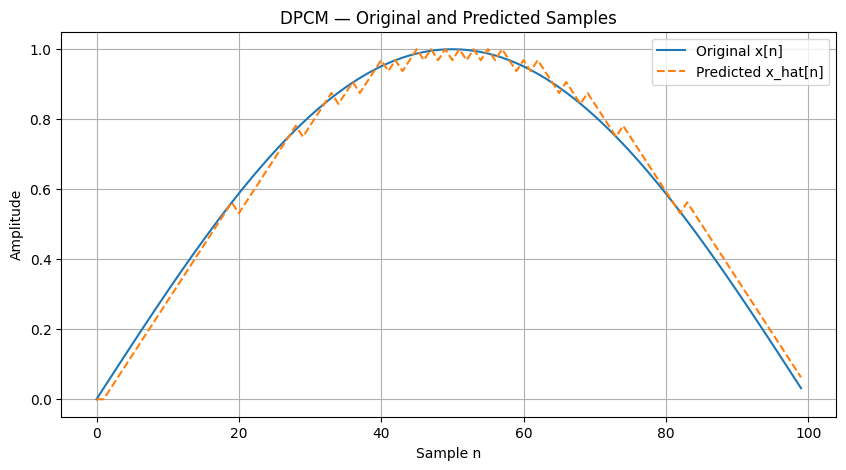

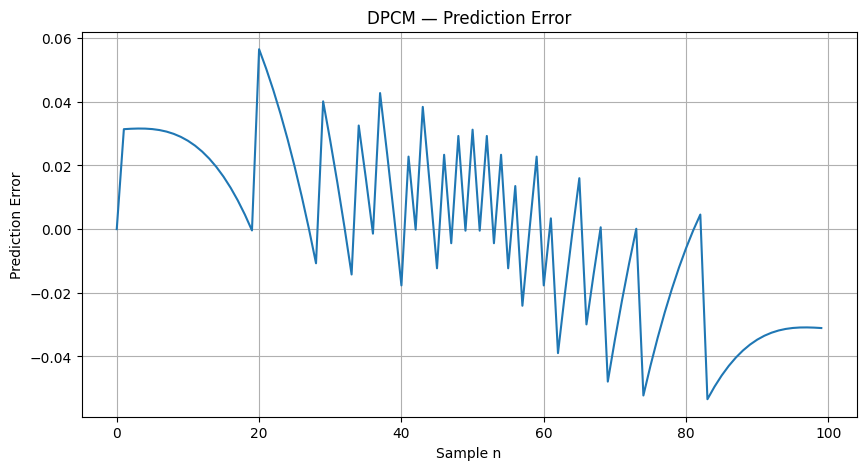

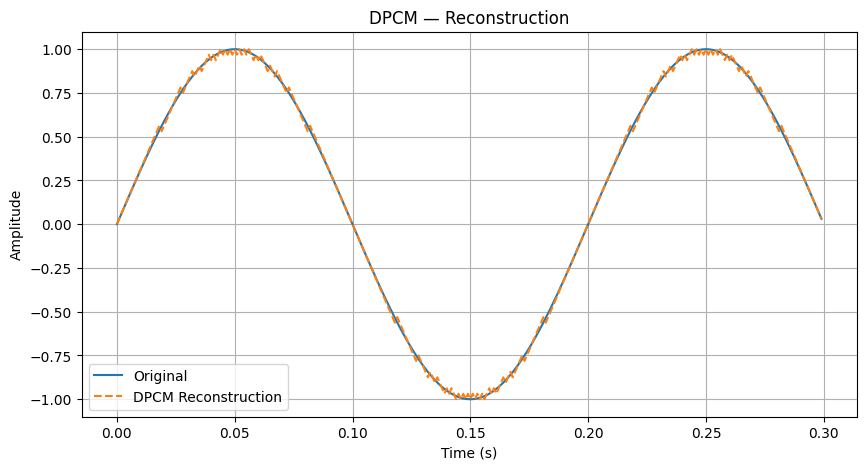

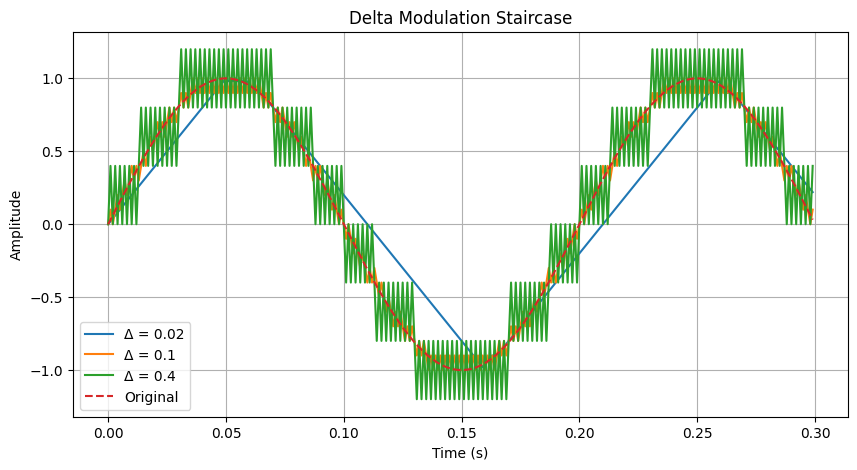

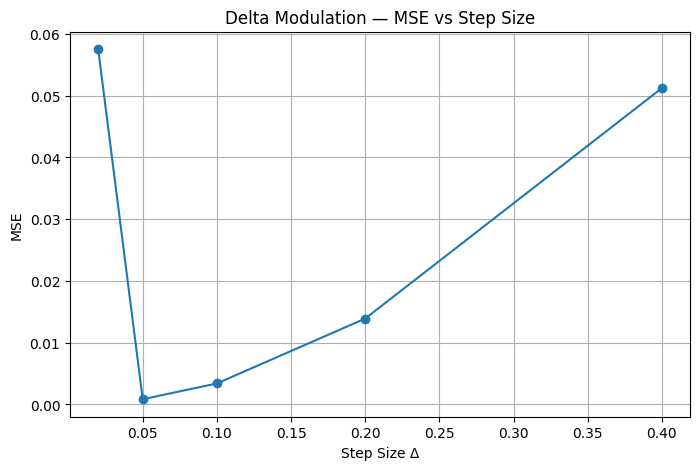

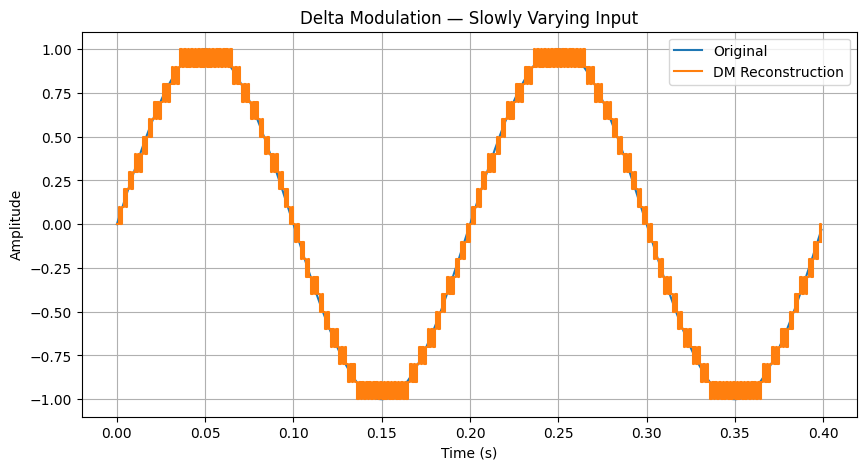

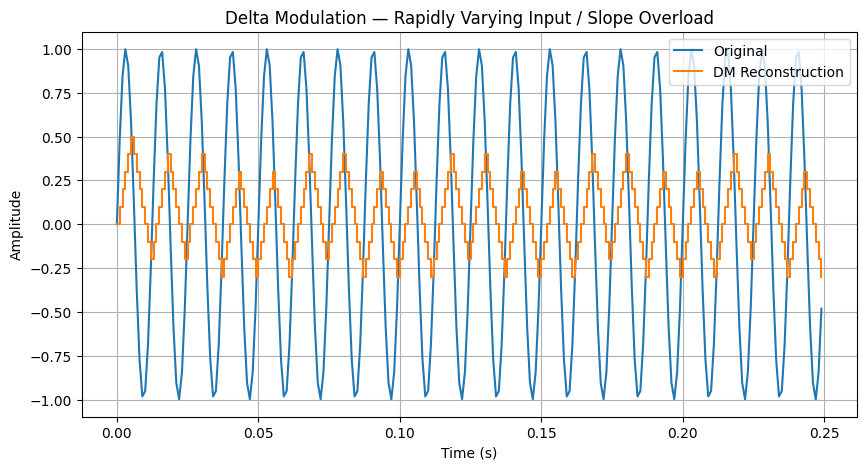



FINAL RESULTS


,Method,Frequency (Hz),Step / Quantizer,MSE
0,PCM - Slow,5,0.1250,0.001501
1,DPCM - Slow,5,0.0625,0.000271
2,PCM - Fast,80,0.1250,0.001997
3,DPCM - Fast,80,0.0625,0.000462
4,DM - Slow Δ=0.02,5,0.0200,0.057520
5,DM - Slow Δ=0.10,5,0.1000,0.003398
6,DM - Slow Δ=0.40,5,0.4000,0.051219
7,DM - Fast Δ=0.10,80,0.1000,0.415044




OBSERVATION AND INTERPRETATION

1. DPCM uses the previous reconstructed sample as the first-order
   prediction.

2. Since adjacent samples of a slowly varying signal are highly
   correlated, the prediction error is much smaller than the original
   signal.

3. DPCM transmits the quantized prediction error instead of the complete
   sample, thereby reducing sample redundancy.

4. In Delta Modulation, the reconstructed signal changes by exactly
   +Δ or −Δ at every sampling instant.

5. A small step size provides better amplitude resolution but can cause
   granular noise because the staircase may oscillate around the input.

6. A large step size can follow rapidly changing portions better, but
   produces a coarse staircase and larger quantization error.

7. Slope-overload distortion occurs when the input changes faster than
   the staircase can follow.

8. Therefore, with the same Δ, the rapidly varying 80-Hz signal shows
   much stronger slope-overload distortion than the 5-Hz sig

In [2]:
# ============================================================
# EXPERIMENT 5 — DPCM AND DELTA MODULATION
# Google Colab Compatible Version
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 70)
print("EXPERIMENT 5 — DPCM AND DELTA MODULATION")
print("=" * 70)


# ============================================================
# 1. SIGNAL GENERATION
# ============================================================

fs = 1000                  # Sampling frequency
duration = 1               # Signal duration in seconds

t = np.arange(0, duration, 1/fs)
N = len(t)

A = 1.0                    # Signal amplitude

# Slowly varying signal
f_slow = 5
x_slow = A * np.sin(2 * np.pi * f_slow * t)

# Rapidly varying signal
f_fast = 80
x_fast = A * np.sin(2 * np.pi * f_fast * t)

print("\nSignal parameters:")
print("Sampling frequency =", fs, "Hz")
print("Slow signal frequency =", f_slow, "Hz")
print("Fast signal frequency =", f_fast, "Hz")


# ============================================================
# 2. PCM QUANTIZATION
# ============================================================

def pcm_quantizer(x, bits=4, xmin=-1, xmax=1):

    L = 2 ** bits
    delta = (xmax - xmin) / L

    q = np.floor((x - xmin) / delta) * delta \
        + xmin + delta / 2

    q = np.clip(
        q,
        xmin + delta / 2,
        xmax - delta / 2
    )

    mse = np.mean((x - q) ** 2)

    return q, mse, delta


# PCM for slow signal
pcm_slow, pcm_mse_slow, pcm_delta = pcm_quantizer(x_slow)

# PCM for fast signal
pcm_fast, pcm_mse_fast, _ = pcm_quantizer(x_fast)


# ============================================================
# 3. FIRST-ORDER DPCM
# ============================================================

def dpcm_encode_decode(x, bits=4):

    N = len(x)

    prediction = np.zeros(N)
    prediction_error = np.zeros(N)
    quantized_error = np.zeros(N)
    reconstructed = np.zeros(N)

    # Prediction-error range
    xmin = -0.5
    xmax = 0.5

    L = 2 ** bits
    delta = (xmax - xmin) / L

    # First sample
    reconstructed[0] = x[0]

    prediction[0] = 0

    prediction_error[0] = x[0]

    index = int(
        np.floor(
            (prediction_error[0] - xmin) / delta
        )
    )

    index = np.clip(index, 0, L - 1)

    quantized_error[0] = (
        xmin + (index + 0.5) * delta
    )

    for n in range(1, N):

        # First-order prediction
        prediction[n] = reconstructed[n - 1]

        # Prediction error
        prediction_error[n] = (
            x[n] - prediction[n]
        )

        # Quantization
        index = int(
            np.floor(
                (prediction_error[n] - xmin) / delta
            )
        )

        index = np.clip(index, 0, L - 1)

        quantized_error[n] = (
            xmin + (index + 0.5) * delta
        )

        # Reconstruction
        reconstructed[n] = (
            prediction[n] + quantized_error[n]
        )

    mse = np.mean(
        (x - reconstructed) ** 2
    )

    return (
        prediction,
        prediction_error,
        quantized_error,
        reconstructed,
        mse,
        delta
    )


# DPCM slow input
(
    prediction_slow,
    error_slow,
    qerror_slow,
    dpcm_slow,
    dpcm_mse_slow,
    dpcm_delta
) = dpcm_encode_decode(x_slow)


# DPCM fast input
(
    prediction_fast,
    error_fast,
    qerror_fast,
    dpcm_fast,
    dpcm_mse_fast,
    _
) = dpcm_encode_decode(x_fast)


# ============================================================
# 4. DPCM RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("DPCM RESULTS")
print("=" * 70)

print("\nPCM MSE (5 Hz)  =", round(pcm_mse_slow, 8))
print("DPCM MSE (5 Hz) =", round(dpcm_mse_slow, 8))

print("\nPCM MSE (80 Hz)  =", round(pcm_mse_fast, 8))
print("DPCM MSE (80 Hz) =", round(dpcm_mse_fast, 8))

print("\nDPCM prediction:")
print("x_hat[n] = x_reconstructed[n-1]")

print("\nDPCM quantizer step =", dpcm_delta)


# ============================================================
# 5. DELTA MODULATION
# ============================================================

def delta_modulation(x, step):

    N = len(x)

    staircase = np.zeros(N)

    bits = np.zeros(N, dtype=int)

    # Initial value
    staircase[0] = x[0]

    # DM encoding
    for n in range(1, N):

        if x[n] >= staircase[n - 1]:

            bits[n] = 1

            staircase[n] = (
                staircase[n - 1] + step
            )

        else:

            bits[n] = 0

            staircase[n] = (
                staircase[n - 1] - step
            )

    reconstructed = staircase.copy()

    # Mean square error
    mse = np.mean(
        (x - reconstructed) ** 2
    )

    # ========================================================
    # Mandatory validation
    # Every staircase change must be exactly +Delta or -Delta
    # ========================================================

    changes = np.diff(staircase)

    # Ignore the first change if required
    changes = changes[1:]

    positive_steps = np.isclose(
        changes,
        step,
        atol=1e-10
    )

    negative_steps = np.isclose(
        changes,
        -step,
        atol=1e-10
    )

    validation = np.all(
        positive_steps | negative_steps
    )

    return (
        staircase,
        bits,
        reconstructed,
        mse,
        validation
    )


# ============================================================
# 6. DIFFERENT STEP SIZES
# ============================================================

step_sizes = [
    0.02,
    0.05,
    0.10,
    0.20,
    0.40
]

mse_values = []
validation_values = []

for step in step_sizes:

    staircase, bits, reconstruction, mse, validation = \
        delta_modulation(x_slow, step)

    mse_values.append(mse)

    validation_values.append(
        "PASS" if validation else "FAIL"
    )


dm_table = pd.DataFrame({

    "Step Size Δ": step_sizes,

    "MSE": mse_values,

    "Step Validation": validation_values

})


print("\n")
print("=" * 70)
print("DELTA MODULATION — MSE VS STEP SIZE")
print("=" * 70)

display(dm_table)


# ============================================================
# 7. SMALL, MODERATE AND LARGE STEP SIZE
# ============================================================

small_step = 0.02
moderate_step = 0.10
large_step = 0.40

_, _, _, mse_small, valid_small = \
    delta_modulation(x_slow, small_step)

_, _, _, mse_moderate, valid_moderate = \
    delta_modulation(x_slow, moderate_step)

_, _, _, mse_large, valid_large = \
    delta_modulation(x_slow, large_step)


step_case_table = pd.DataFrame({

    "Case": [
        "Small",
        "Moderate",
        "Large"
    ],

    "Step Size Δ": [
        small_step,
        moderate_step,
        large_step
    ],

    "MSE": [
        mse_small,
        mse_moderate,
        mse_large
    ],

    "Validation": [
        "PASS" if valid_small else "FAIL",
        "PASS" if valid_moderate else "FAIL",
        "PASS" if valid_large else "FAIL"
    ]
})


print("\n")
print("=" * 70)
print("SMALL / MODERATE / LARGE STEP SIZE")
print("=" * 70)

display(step_case_table)


# ============================================================
# 8. SLOW VS FAST INPUT
# ============================================================

test_step = 0.10

(
    staircase_slow,
    bits_slow,
    reconstruction_slow,
    mse_dm_slow,
    validation_slow
) = delta_modulation(
    x_slow,
    test_step
)


(
    staircase_fast,
    bits_fast,
    reconstruction_fast,
    mse_dm_fast,
    validation_fast
) = delta_modulation(
    x_fast,
    test_step
)


# ============================================================
# 9. SLOPE OVERLOAD TEST
# ============================================================

def slope_overload_percentage(x, step):

    change = np.abs(np.diff(x))

    percentage = (
        np.sum(change > step)
        / len(change)
    ) * 100

    return percentage


slope_slow = slope_overload_percentage(
    x_slow,
    test_step
)

slope_fast = slope_overload_percentage(
    x_fast,
    test_step
)


print("\n")
print("=" * 70)
print("MANDATORY STEP VALIDATION")
print("=" * 70)

print(
    "Slow signal:",
    "PASS" if validation_slow else "FAIL"
)

print(
    "Fast signal:",
    "PASS" if validation_fast else "FAIL"
)


print("\n")
print("=" * 70)
print("SLOPE OVERLOAD TEST")
print("=" * 70)

print(
    f"Slow signal (5 Hz): {slope_slow:.2f}%"
)

print(
    f"Fast signal (80 Hz): {slope_fast:.2f}%"
)


# ============================================================
# 10. PLOT 1 — ORIGINAL VS PREDICTED
# ============================================================

samples = np.arange(100)

plt.figure(figsize=(10, 5))

plt.plot(
    samples,
    x_slow[:100],
    label="Original x[n]"
)

plt.plot(
    samples,
    prediction_slow[:100],
    "--",
    label="Predicted x_hat[n]"
)

plt.xlabel("Sample n")
plt.ylabel("Amplitude")

plt.title(
    "DPCM — Original and Predicted Samples"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 11. PLOT 2 — PREDICTION ERROR
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    samples,
    error_slow[:100]
)

plt.xlabel("Sample n")
plt.ylabel("Prediction Error")

plt.title(
    "DPCM — Prediction Error"
)

plt.grid(True)

plt.show()


# ============================================================
# 12. PLOT 3 — DPCM RECONSTRUCTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    t[:300],
    x_slow[:300],
    label="Original"
)

plt.plot(
    t[:300],
    dpcm_slow[:300],
    "--",
    label="DPCM Reconstruction"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.title(
    "DPCM — Reconstruction"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 13. PLOT 4 — DELTA STAIRCASE
# ============================================================

plt.figure(figsize=(10, 5))

for step in [0.02, 0.10, 0.40]:

    staircase, _, _, _, _ = \
        delta_modulation(
            x_slow[:300],
            step
        )

    plt.plot(
        t[:300],
        staircase,
        label=f"Δ = {step}"
    )


plt.plot(
    t[:300],
    x_slow[:300],
    "--",
    label="Original"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.title(
    "Delta Modulation Staircase"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 14. PLOT 5 — MSE VS STEP SIZE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    step_sizes,
    mse_values,
    "o-"
)

plt.xlabel("Step Size Δ")

plt.ylabel("MSE")

plt.title(
    "Delta Modulation — MSE vs Step Size"
)

plt.grid(True)

plt.show()


# ============================================================
# 15. PLOT 6 — SLOWLY VARYING INPUT
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    t[:400],
    x_slow[:400],
    label="Original"
)

plt.step(
    t[:400],
    reconstruction_slow[:400],
    where="post",
    label="DM Reconstruction"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.title(
    "Delta Modulation — Slowly Varying Input"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 16. PLOT 7 — RAPIDLY VARYING INPUT
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    t[:250],
    x_fast[:250],
    label="Original"
)

plt.step(
    t[:250],
    reconstruction_fast[:250],
    where="post",
    label="DM Reconstruction"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.title(
    "Delta Modulation — Rapidly Varying Input / Slope Overload"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 17. FINAL RESULTS TABLE
# ============================================================

final_table = pd.DataFrame({

    "Method": [
        "PCM - Slow",
        "DPCM - Slow",
        "PCM - Fast",
        "DPCM - Fast",
        "DM - Slow Δ=0.02",
        "DM - Slow Δ=0.10",
        "DM - Slow Δ=0.40",
        "DM - Fast Δ=0.10"
    ],

    "Frequency (Hz)": [
        5,
        5,
        80,
        80,
        5,
        5,
        5,
        80
    ],

    "Step / Quantizer": [
        pcm_delta,
        dpcm_delta,
        pcm_delta,
        dpcm_delta,
        0.02,
        0.10,
        0.40,
        0.10
    ],

    "MSE": [
        pcm_mse_slow,
        dpcm_mse_slow,
        pcm_mse_fast,
        dpcm_mse_fast,
        mse_small,
        mse_moderate,
        mse_large,
        mse_dm_fast
    ]
})


print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

display(final_table)


# ============================================================
# 18. SAVE CSV FILES
# ============================================================

dm_table.to_csv(
    "DM_MSE_vs_Step_Size.csv",
    index=False
)

step_case_table.to_csv(
    "DM_Step_Size_Cases.csv",
    index=False
)

final_table.to_csv(
    "Experiment_5_Final_Results.csv",
    index=False
)


# ============================================================
# 19. OBSERVATION AND INTERPRETATION
# ============================================================

print("\n")
print("=" * 70)
print("OBSERVATION AND INTERPRETATION")
print("=" * 70)

print("""
1. DPCM uses the previous reconstructed sample as the first-order
   prediction.

2. Since adjacent samples of a slowly varying signal are highly
   correlated, the prediction error is much smaller than the original
   signal.

3. DPCM transmits the quantized prediction error instead of the complete
   sample, thereby reducing sample redundancy.

4. In Delta Modulation, the reconstructed signal changes by exactly
   +Δ or −Δ at every sampling instant.

5. A small step size provides better amplitude resolution but can cause
   granular noise because the staircase may oscillate around the input.

6. A large step size can follow rapidly changing portions better, but
   produces a coarse staircase and larger quantization error.

7. Slope-overload distortion occurs when the input changes faster than
   the staircase can follow.

8. Therefore, with the same Δ, the rapidly varying 80-Hz signal shows
   much stronger slope-overload distortion than the 5-Hz signal.

9. The mandatory validation confirms that each DM staircase transition
   is exactly +Δ or −Δ.

10. The MSE-versus-step-size curve demonstrates the trade-off between
    granular noise and tracking/slope-overload distortion.
""")

print("\nExperiment 5 completed successfully!")
